# DS150 | Module 2 Activity 1 (3Q2324)
<i> taxi dataset </i> | <span style="color:Brown;"> Predicting Fare Amount and Taxi Provider </span> 

<span style="color:Orange;"> Group 6 Members: </span>  
Aguaviva, Christopher  
Baluyot, Kent  
Berida, Ronabelle  


***

#### <span style="color:Orange;">  Table of Contents: </span>

I. Executive Summary

II. Problem Statement

III. Motivations

IV. Data Preparation

V. Exploratory Data Analysis

VI. Machine Learning

VII. Deep Learning
  
VIII. Result and discussion

IX. Conclusion and Recommendations

***

## <span style="color:Orange;"> I. Executive Summary </span>

The analysis began with data preprocessing to enhance data quality. Unique providers and irrelevant categories were removed, and negative or inconsistent values were adjusted or eliminated. Outliers were addressed, and the dataset was thoroughly cleaned. In exploratory data analysis (EDA), univariate and multivariate analyses were conducted, revealing insights into taxi ride characteristics and correlations between variables.

Machine learning models were trained to predict fare amounts using mileage, duration, and speed, achieving satisfactory results with low mean squared error and high R-squared values. Deep learning models were also explored, with a focus on predicting fare amounts and taxi provider names. While the initial deep learning model showed room for improvement, subsequent iterations with added layers and parameter adjustments enhanced performance. Predictive accuracy for taxi provider names reached around 37%, indicating potential for accurate classification.


## <span style="color:Orange;">  II. Problem Statement </span>

The motivation behind this project stems from the need to enhance the efficiency and accuracy of fare prediction in the taxi industry. By developing robust predictive models, taxi companies can optimize their pricing strategies, improve customer satisfaction, and streamline operational processes. Additionally, accurate fare prediction can aid passengers in budgeting for their trips, leading to greater transparency and trust in taxi services. Moreover, classifying taxi provider names based on ride characteristics can offer valuable insights for market analysis, enabling companies to understand customer preferences and make informed business decisions. Overall, by leveraging machine learning and deep learning techniques, this project aims to address real-world challenges in the taxi industry and drive innovation in the realm of transportation services.




## <span style="color:Orange;"> III. Motivation </span>

The motivation behind this project stems from the need to enhance the efficiency and accuracy of fare prediction in the taxi industry. By developing robust predictive models, taxi companies can optimize their pricing strategies, improve customer satisfaction, and streamline operational processes. Additionally, accurate fare prediction can aid passengers in budgeting for their trips, leading to greater transparency and trust in taxi services. Moreover, classifying taxi provider names based on ride characteristics can offer valuable insights for market analysis, enabling companies to understand customer preferences and make informed business decisions. Overall, by leveraging machine learning and deep learning techniques, this project aims to address real-world challenges in the taxi industry and drive innovation in the realm of transportation services.


***

Importing Modules and Initiliazing a Class

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow import keras

from datetime import datetime
from datetime import timedelta

plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 40)   # displays max columns of the DataFrame 
color_pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
# for print content visualizations
class colors:
    GREEN = '\033[92m'
    RED = '\033[91m'
    END = '\033[0m'

In [3]:
import time
start_legacy = time.time()
print("Timer started...")

Timer started...


*For summary: Total runtime of end-to-end pipeline fare prediction using Machine Learning model and taxi provider prediction with Deep Learning model is 2390.83 seconds*


## <span style="color:Orange;"> IV. Data Preparation </span>


As the data is too large for the interpreter to handle, we decided to create a list and divide the dataset into chunks of data. At the end, the data in the list are concatenated together and transformed into a DataFrame format. This method is to ensure faster and more efficient storage of data.

*Recent changes: Since I wanted to run the entire file again to get the file's time rundown, a portion of the code has been change due to my laptop's memory constraints. I combined the date conversion columns and column targeting with the batch processing of 11m rows of data. The entire core of the original ipynb file is still retained*

In [4]:
chunk_size = 50000 
processed_chunks = []
target_columns = ['ID', 'StartDateTime', 'EndDateTime', 'PROVIDER NAME', 'FareAmount', 'PaymentType', 'Milage', 'Duration']

path = "../data/taxi_final.csv"    # replace the path if the taxi_final.csv is in another folder

# Initialize the reader with chunksize
reader = pd.read_csv(path, usecols=target_columns, chunksize=chunk_size, low_memory=False)

for chunk in reader:
    # Convert to datetime
    chunk['StartDateTime'] = pd.to_datetime(chunk['StartDateTime'], utc=True, errors='coerce')
    chunk['EndDateTime'] = pd.to_datetime(chunk['EndDateTime'], utc=True, errors='coerce')

    # Extract date and convert back to datetime
    chunk['StartDateTime'] = chunk['StartDateTime'].dt.date
    chunk['StartDateTime'] = pd.to_datetime(chunk['StartDateTime'])

    chunk['EndDateTime'] = chunk['EndDateTime'].dt.date
    chunk['EndDateTime'] = pd.to_datetime(chunk['EndDateTime'])
    
    # Store the processed chunk
    processed_chunks.append(chunk)

# Combine everything back into a single dataframe if RAM allows
df = pd.concat(processed_chunks, ignore_index=True)

In [4]:
# Dividing the dataset into chunks of data and then combining it
path = "../data/taxi_final.csv"    # replace the path if the taxi_final.csv is in another folder

data_chunks = []
chunksize = 500000       # Specify chunksize (number of rows to read at a time)

for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False):
    data_chunks.append(chunk)

df = pd.concat(data_chunks, ignore_index=True)

In [5]:
#renaming the column with an inconsistent structure for better reading
df.rename(columns={'PROVIDER NAME': 'ProviderName', 'Milage': 'Mileage'}, inplace=True)  

In [6]:
df.head(2)

,Type,ProviderName,StartDateTime,DateCreated,ID,ExternalID,FareAmount,GratuityAmount,SurchargeAmount,ExtraFareAmount,TollAmount,TotalAmount,PaymentType,StartDateTime.1,EndDateTime,OriginStreetNumber,OriginStreetName,OriginCity,OriginState,OriginZip,OriginLatitude,OriginLongitude,DestinationStreetNumber,DestinationStreetName,DestinationCity,DestinationState,DestinationZip,DestinationLatitude,DestinationLongitude,Mileage,Duration,Unnamed: 31
0,1.0,Yellow Cab,2017-12-01 00:01:06.0000000 +00:00,2017-12-01 00:09:54.4033333 +00:00,B467__82709__2017-12-01T00:09:54.403_36188498,36188498,7.57,1.83,0.25,0.25,0.0,11.00,1.0,2017-12-01 00:01:06.0000000 +00:00,2017-12-01 00:09:51.0000000 +00:00,NaN,"2660 WOODLEY RD NW, WASHINGTON, DC 20008, USA",NaN,DC,20008,38.92492,-77.05333,NaN,"1526 K ST NW, WASHINGTON, DC 20005, USA",NaN,DC,20005,38.90232,-77.03560,2.11,8.0,NaN
1,1.0,Yellow Cab,2017-12-01 00:05:27.0000000 +00:00,2017-12-01 00:11:43.4666667 +00:00,B369__52337__2017-12-01T00:11:43.467_36188500,36188500,4.60,0.00,0.25,1.25,0.0,7.47,1.0,2017-12-01 00:05:27.0000000 +00:00,2017-12-01 00:11:40.0000000 +00:00,NaN,"400 7TH ST NW, WASHINGTON, DC 20004, USA",NaN,DC,20004,38.89493,-77.02221,NaN,"1335 F ST NW, WASHINGTON, DC 20004, USA",NaN,DC,20004,38.89737,-77.03103,0.62,6.0,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11937645 entries, 0 to 11937644
Data columns (total 33 columns):
 #   Column                   Dtype              
---  ------                   -----              
 0   Type                     object             
 1   ProviderName             str                
 2   StartDateTime            str                
 3   DateCreated              datetime64[ns, UTC]
 4   ID                       str                
 5   ExternalID               object             
 6   FareAmount               float64            
 7   GratuityAmount           float64            
 8   SurchargeAmount          float64            
 9   ExtraFareAmount          float64            
 10  TollAmount               float64            
 11  TotalAmount              float64            
 12  PaymentType              float64            
 13  StartDateTime.1          str                
 14  EndDateTime              str                
 15  OriginStreetNumber       object          

### Data Exploration
<span style="font-size:larger;"> Both <i> StartDateTime </i> and <i> StartDateTime.1 </i> columns are the same, will remove the former  </span>  
<i> New changes: The mentioned columns will not be used and only the relevant columns (listed below) will be utilized. </i>  
    The DataFrame example below only displays the similarities of the mentioned column as an insight.

In [6]:
df[['StartDateTime', 'StartDateTime.1', 'EndDateTime']].head(2)

,StartDateTime,StartDateTime.1,EndDateTime
0,2017-12-01 00:01:06.0000000 +00:00,2017-12-01 00:01:06.0000000 +00:00,2017-12-01 00:09:51.0000000 +00:00
1,2017-12-01 00:05:27.0000000 +00:00,2017-12-01 00:05:27.0000000 +00:00,2017-12-01 00:11:40.0000000 +00:00


***
In this dataset, we focused on indentifying columns that might be a duplicate of another and determining each of the columns' null value. Since the group's objective is only to obtain the dates of each rows as a reference for time analysis, the group opted to use the column `DateCreated` and removed the time allocated with it for the better usage of the column later on in the EDA, ML, and DL stage. Afterwards, we removed the irrelevant features of the dataset, choosing only the ones with interpretability potential.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11937645 entries, 0 to 11937644
Data columns (total 8 columns):
 #   Column         Dtype        
---  ------         -----        
 0   ProviderName   str          
 1   StartDateTime  datetime64[s]
 2   ID             str          
 3   FareAmount     float64      
 4   PaymentType    float64      
 5   EndDateTime    datetime64[s]
 6   Mileage        float64      
 7   Duration       float64      
dtypes: datetime64[s](2), float64(4), str(2)
memory usage: 728.6 MB


In [8]:
print("Missing Values")
print(colors.GREEN + f"{dict(df.isnull().sum())}" + colors.END)

Missing Values
{'ID': 12, 'Date': 135, 'ProviderName': 13, 'FareAmount': 64653, 'PaymentType': 135, 'Mileage': 107460, 'Duration': 359236}


In [8]:
old_rows = df.shape[0]

Since there are many columns with null values, it is necessary to drop indexes with null values for a cleaner data. The group opted on removing the observations with present null values instead of imputing since the data is large enough to cover EDA and ML even if portion is removed.

Additionally, many of the missing values in the column `Duration` (359,326 rows) also misses values from the remaining other columns except for FareAmount and TotalAmount. It would be more beneficial to remove the missing values.

In [6]:
df.dropna(subset=['Duration', 'FareAmount'], inplace=True)

In [12]:
new_rows = df.shape[0]

print("Number of rows/observations:")
print(f"Old: " + colors.GREEN + f"{old_rows:,}" + colors.END)
print(f"New: " + colors.GREEN + f"{new_rows:,}" + colors.END)

Number of rows/observations:
Old: 11,937,645
New: 11,513,770


In [13]:
print("Missing Values after Cleaning:")
print(colors.GREEN + f"{dict(df.isnull().sum())}" + colors.END)

Missing Values after Cleaning:
{'ID': 0, 'Date': 0, 'ProviderName': 0, 'FareAmount': 0, 'PaymentType': 0, 'Mileage': 0, 'Duration': 0}


### Duplicate Data 
We determined that each of the vehicle has a unique identification, and we based the ID variable as identification of that certain vehicle in a certain ride. The dataset has many occurring duplicate observations in the dataset. One of the IDs present below: `G836__74262__2017-02-01T00:16:43.763_27245853`, is shown to have another duplicate row (which also has the same content for every other columns). To avoid this, it is essential to remove the duplicate observations for a more accurate data.

In [9]:
df.query('ID == "G836__74262__2017-02-01T00:16:43.763_27245853"')

,ProviderName,StartDateTime,ID,FareAmount,PaymentType,EndDateTime,Mileage,Duration
1633473,UVC,2017-02-01,G836__74262__2017-02-01T00:16:43.763_27245853,6.22,1.0,2017-02-01,0.8,6.0
4324424,UVC,2017-02-01,G836__74262__2017-02-01T00:16:43.763_27245853,6.22,1.0,2017-02-01,0.8,6.0


These are the rows that has duplicates, or observations recorded more than once in this dataset

In [14]:
# counts the number of duplicated rows
print(f"Number of duplicated unique IDs: " + colors.GREEN + f"{df.duplicated(subset=['ID']).sum()}" + colors.END)

Number of duplicated unique IDs: 46


In [ ]:
## unmodified cell for output display
df.loc[df.duplicated(subset=['ID'])]   

,ID,Date,ProviderName,FareAmount,PaymentType,Mileage,Duration
4324424,G836__74262__2017-02-01T00:16:43.763_27245853,2017-02-01,UVC,6.22,1.0,0.80,6.0
5528924,J665__52839__2017-03-02T19:10:12.433_28411912,2017-03-02,DC VIP Cab,18.64,1.0,6.70,17.0
5576329,D275__73469__2017-03-01T15:03:31.097_28350681,2017-03-01,VeriFone,9.19,2.0,1.90,10.0
5576367,A245__73292__2017-03-01T15:02:03.490_28350630,2017-03-01,VeriFone,7.30,1.0,1.38,7.0
5583472,F826__63431__2017-03-01T00:51:37.643_28329401,2017-03-01,UVC,18.10,1.0,6.80,13.0
6635922,B542__73126__2017-08-01T00:14:30.900_34223388,2017-08-01,Yellow Cab,18.10,2.0,8.98,19.0
6635929,B866__81066__2017-08-01T00:18:02.940_34224619,2017-08-01,UVC,8.65,2.0,2.30,7.0
6635958,B691__77407__2017-08-01T00:39:59.520_34224656,2017-08-01,UVC,29.98,1.0,11.70,23.0
6640677,A633__52025__2017-08-01T15:02:19.293_34237244,2017-08-01,Transco,5.95,2.0,0.87,6.0
6640694,B768__82503__2017-08-01T15:03:27.003_34237260,2017-08-01,VeriFone,22.15,1.0,8.18,17.0


#### Removing duplicates from the dataset 

In [7]:
df = df.loc[~df.duplicated(subset=['ID'])].reset_index(drop=True).copy()
print(f"Number of duplicated rows after changes: " + colors.GREEN + f"{df.duplicated(subset=['ID']).sum()}" + colors.END)

Number of duplicated rows after changes: 0


In [ ]:
## unmodified cell for output display
print(f"Current number of Rows: " + colors.GREEN + f"{df.shape[0]:,}" + colors.END)

Current number of Rows: 11,513,724


Unnecessary categories can lead to an issue with the visualization later on, that is why the categories `Taxi Transportation` and `data unavailable` are removed.

In [12]:
print(f"Number of Taxi Providers: \n\n{df['ProviderName'].value_counts()}")

Number of Taxi Providers: 

ProviderName
CMT                2191385
UVC                2080295
DC VIP Cab         1454463
Hitch              1427781
Transco            1417478
VeriFone           1103824
Yellow Cab          898551
Bay Cab             573648
Grand Cab           274125
Capitol Cab          57179
My taxi Control      34966
DFHV Limo               29
Name: count, dtype: int64


In [46]:
print("Number of Taxi Providers: ")
print(colors.GREEN + f"{list(df['ProviderName'].unique())}" + colors.END)

Number of Taxi Providers: 
['Yellow Cab', 'Transco', 'VeriFone', 'DC VIP Cab', 'CMT', 'Capitol Cab', 'UVC', 'Bay Cab', 'Grand Cab', 'My taxi Control', 'Hitch', 'DFHV Limo']


### Removing rows that have a negative value on numerical columns (FareAmount, Mileage, Duration)
There are some inconsistent rows that had a negative value for the numerical dtypes column. For more accurate representation of data, the group opted to transform the negative values into positive values, since there might be some error on inputting the data which turned the input values into negative. Additionally, any inconsistent rows will be deleted as well, such as:
- Other numerical values that has 0.0 values
- The <span style="color:blue;"> Duration </span> of a taxi ride being 0.0 but the <span style="color:blue;"> FareAmount </span> is more than <span style="color:blue;"> 0 </span>
- <span style="color:red;"> Mileage </span> that doesn't seem to fit the values with <span style="color:red;"> Duration </span> and <span style="color:red;"> FareAmount </span>, etc.

#### Negative Values

In [16]:
print(f"Number of rows that has a negative values in Duration Column:    " + colors.GREEN + f"{df.query('Duration < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in Mileage Column:    " + colors.GREEN + f"{df.query('Mileage < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in FareAmount Column: " + colors.GREEN + f"{df.query('FareAmount < 0.0').shape[0]}" + colors.END)

Number of rows that has a negative values in Duration Column:    58
Number of rows that has a negative values in Mileage Column:    526
Number of rows that has a negative values in FareAmount Column: 649


In [8]:
# Transform negative values into positive values
df.loc[df['Duration'] < 0, 'Duration'] *= -1
df.loc[df['Mileage'] < 0, 'Mileage'] *= -1
df.loc[df['FareAmount'] < 0, 'FareAmount'] *= -1

In [18]:
print(f"Number of rows with negative values in Duration Column:   " + colors.GREEN + f"{df.query('Duration < 0.0').shape[0]}" + colors.END)
print(f"Number of rows with negative values in Mileage Column:    " + colors.GREEN + f"{df.query('Mileage < 0.0').shape[0]}" + colors.END)
print(f"Number of rows with negative values in FareAmount Column: " + colors.GREEN + f"{df.query('FareAmount < 0.0').shape[0]}" + colors.END)

Number of rows with negative values in Duration Column:   0
Number of rows with negative values in Mileage Column:    0
Number of rows with negative values in FareAmount Column: 0


#### Dropping rows that has a value of 0.0 (on the mentioned 3 numerical columns)

In [20]:
print(f"Number of rows with 0.0 in Duration Column:  " + colors.GREEN + f"{df.query('Duration == 0.0').shape[0]:,}" + colors.END)
print(f"Number of rows with 0.0 in Mileage Column:   " + colors.GREEN + f"{df.query('Mileage == 0.0').shape[0]:,}" + colors.END)
print(f"Number of rows with 0.0 in FareAmount Column: " + colors.GREEN + f"{df.query('FareAmount == 0.0').shape[0]:,}" + colors.END)

Number of rows with 0.0 in Duration Column:  136,982
Number of rows with 0.0 in Mileage Column:   495,517
Number of rows with 0.0 in FareAmount Column: 14,942


In [21]:
df.query("Mileage == 0").head(3)

,ProviderName,StartDateTime,ID,FareAmount,PaymentType,EndDateTime,Mileage,Duration
14,Yellow Cab,2017-12-01,B358__72854__2017-12-01T00:26:53.370_36188515,3.25,2.0,2017-12-01,0.0,0.0
48,Yellow Cab,2017-12-01,K649__64634__2017-12-01T01:10:13.160_36188553,3.52,2.0,2017-12-01,0.0,0.0
55,Yellow Cab,2017-12-01,B338__81299__2017-12-01T01:19:36.200_36188561,3.25,2.0,2017-12-01,0.0,1.0


In [9]:
# Dropping the rows
df.drop(df[df['Duration'] == 0].index, inplace=True)         # dropping duration rows with 0.0
df.drop(df[df['FareAmount'] == 0].index, inplace=True)       # dropping fareamount rows with 0.0
df.drop(df[df['Mileage'] == 0].index, inplace=True)          # dropping mileage rows with 0.0

In [23]:
print(f"Number of rows with 0.0 in Duration Column (new):   " + colors.GREEN + f"{df.query('Duration == 0.0').shape[0]:,}" + colors.END)
print(f"Number of rows with 0.0 in Mileage Column (new):    " + colors.GREEN + f"{df.query('Mileage == 0.0').shape[0]:,}" + colors.END)
print(f"Number of rows with 0.0 in FareAmount Column (new): " + colors.GREEN + f"{df.query('FareAmount == 0.0').shape[0]:,}" + colors.END)

Number of rows with 0.0 in Duration Column (new):   0
Number of rows with 0.0 in Mileage Column (new):    0
Number of rows with 0.0 in FareAmount Column (new): 0


#### Inconsistent Columns
In this section, the data will be filtered with three conditions set by the group. The set conditions are only an estimation to <i> remove the rows with extreme inconsistent column </i> against the other interdependent columns. In this case, if the rows containing a value for `Mileage` is greater than 50 while the `Duration` and `FareAmount` is lower than 30 and 50 respectively, then those rows will be removed.

In [24]:
df[(df['Mileage'] > 50) & (df['Duration'] < 30) & (df['FareAmount'] < 50)].head(3)

,ProviderName,StartDateTime,ID,FareAmount,PaymentType,EndDateTime,Mileage,Duration
3420,Transco,2017-12-01,A611__79712__2017-12-01T16:20:17.090_36196671,5.0,2.0,2017-12-01,5707.75,13.0
3735,Transco,2017-12-01,A611__79712__2017-12-01T16:35:23.310_36196992,5.0,2.0,2017-12-01,5708.49,6.0
6296,Transco,2017-12-01,A611__79712__2017-12-02T04:05:30.197_36202948,5.0,2.0,2017-12-01,5709.02,21.0


In [10]:
conditions = df[(df['Mileage'] > 50) & (df['Duration'] < 30) & (df['FareAmount'] < 50)]
print("There are " + colors.GREEN + f"{conditions.shape[0]:,}" + colors.END + " inconsistent rows.")

There are 65,936 inconsistent rows.


In [11]:
# Dropping the rows
df.drop(conditions.index, inplace=True)              

#### Additional Extreme Inconsistent Rows

In [12]:
df[(df['Mileage'] > 1000)].head(3)

,ProviderName,StartDateTime,ID,FareAmount,PaymentType,EndDateTime,Mileage,Duration
94744,Transco,2017-12-09,K799__53176__2017-12-10T03:16:21.920_36292752,5.00,2.0,2017-12-09,5709.77,30.0
322784,Capitol Cab,2017-12-19,M148__82835__2017-12-25T08:33:20.871Z,5.00,2.0,2017-12-19,5710.15,37.0
340036,Capitol Cab,2017-12-26,A853__91213__2017-12-26T18:38:31.416Z,43.75,2.0,2017-12-26,5481.39,71.0


1000 min Duration is equivalent to 16 hours, which does not seemed ideal in taxi rides. The group will only obtain the dataset that contains Duration that is <i> less than 1000 </i>

In [13]:
# CHANGES_2
conditions_2 = df[(df['Duration'] > 1000)]                               # removes rows when the duration exceeds 1000 mins/16.6 hrs
print("There are " + colors.GREEN + f"{conditions_2.shape[0]:,}" + colors.END + " inconsistent rows.")

There are 496,682 inconsistent rows.


In [14]:
# Dropping the rows
df.drop(conditions_2.index, inplace=True)

 Assuming the max speed for the taxi is <i> 50 miles per hour </i> (60 mins), the group created another column in the dataset which will be called `Speed` and is measured <span style="color:Red;"> Miles per hour (mph) </span>. There are multiple speed limits associated with the types of roads the taxi passes, but in this dataset, the group will use the speed limit of the <i> Interstate Highways </i> in the US, which has a maximum speed limit of 75 mph. Any rows with the speed above 75 mph will be promptly removed.

In [15]:
df['Speed'] = df['Mileage'] / (df['Duration'] / 60)

In [16]:
# CHANGES_3                                                            
conditions_3 = df[(df['Speed'] > 75)]        
print("There are " + colors.GREEN + f"{conditions_3.shape[0]:,}" + colors.END + " inconsistent rows.")

There are 18,882 inconsistent rows.


In [17]:
# Dropping the rows
df.drop(conditions_3.index, inplace=True)

Removing rows with <span style="color:red;"> absurd pricing </span> in contrast with the small Mileage and Duration. (Assuming `FareAmount` is in dollars)

In [18]:
df[(df['FareAmount'] > 500) & (df['Duration'] < 10)].head(3)

,ProviderName,StartDateTime,ID,FareAmount,PaymentType,EndDateTime,Mileage,Duration,Speed
3771842,UVC,2017-01-17,J729__74081__2017-01-17T08:54:37.763_26773513,69600.0,2.0,2017-01-17,1.1,3.0,22.0
3771852,UVC,2017-01-17,J729__74081__2017-01-17T08:54:39.077_26773523,69600.0,2.0,2017-01-17,1.1,2.0,33.0
3771854,UVC,2017-01-17,J729__74081__2017-01-17T08:54:39.317_26773525,69600.0,2.0,2017-01-17,1.1,1.0,66.0


In [19]:
# CHANGES_4
conditions_4 = df[(df['FareAmount'] > 500) & (df['Duration'] < 10)]                 # Removes rows if Taxi Fare Price is too large
print("There are " + colors.GREEN + f"{conditions_4.shape[0]:,}" + colors.END + " inconsistent rows.")

There are 16 inconsistent rows.


In [20]:
# Dropping the rows
df.drop(conditions_4.index, inplace=True)

In [21]:
#CHANGES_5
conditions_5 = df[(df['FareAmount'] > 500)]  

# Dropping the rows
df.drop(conditions_5.index, inplace=True)

In [ ]:
## unmodified cell for output display
print(f"Old number of Rows:     " + colors.GREEN + f"{old_rows:,}" + colors.END)
print(f"Current number of Rows: " + colors.GREEN + f"{df.shape[0]:,}" + colors.END)

### ~~Removing Outliers for better interpretability in EDA~~   
<b> Version_02 </b> Since the data has already been cleaned by its columns/features, it seems unnecessary to remove outliers


## <span style="color: Orange;"> V. Exploratory Data Analysis (EDA) </span>

This section focuses more in exploring the cleaned dataset univariately and multivariately. The dataset has some of observations remove due to outliers.

#### Univariate Analysis

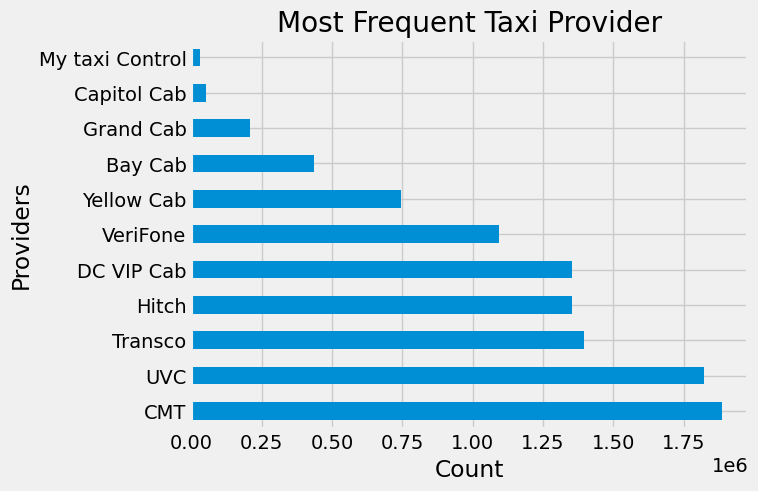

In [23]:
#plotting the Taxi Providers
ax = df['ProviderName'].value_counts().plot(kind='barh', title='Most Frequent Taxi Provider')
ax.set_xlabel('Count')
ax.set_ylabel('Providers')
plt.show()

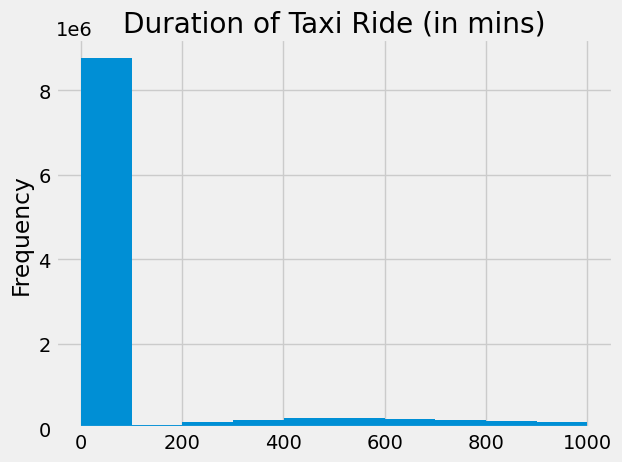

In [24]:
ax_2 = df['Duration'].plot(kind='hist', title='Duration of Taxi Ride (in mins)')  
ax_2.set_ylabel('Frequency')

plt.show()

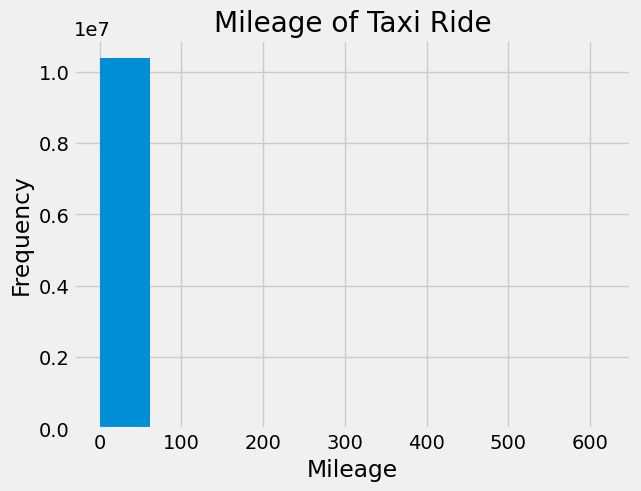

In [25]:
ax_2 = df['Mileage'].plot(kind='hist', title='Mileage of Taxi Ride')     #outliers removed
ax_2.set_xlabel('Mileage')
ax_2.set_ylabel('Frequency')

plt.show()

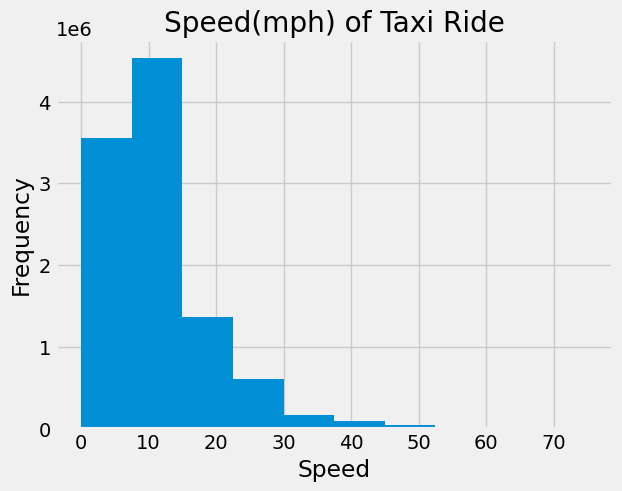

In [26]:
ax_2 = df['Speed'].plot(kind='hist', title='Speed(mph) of Taxi Ride')     #outliers removed
ax_2.set_xlabel('Speed')
ax_2.set_ylabel('Frequency')

plt.show()

#### Multivariate Analysis

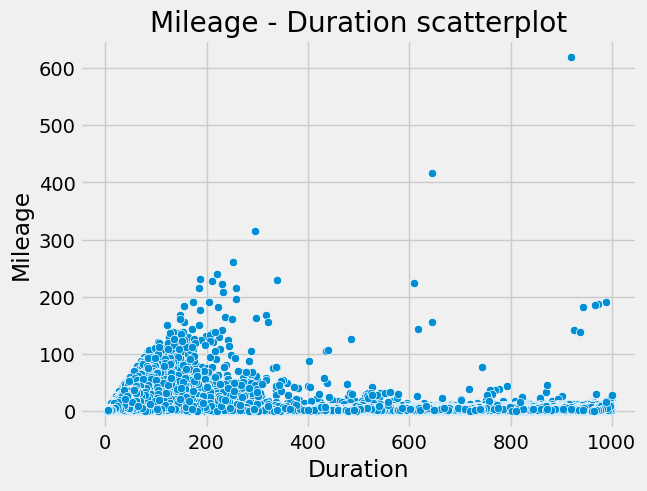

In [27]:
sns.scatterplot(x='Duration', y='Mileage', data=df)
plt.title('Mileage - Duration scatterplot')
plt.show()

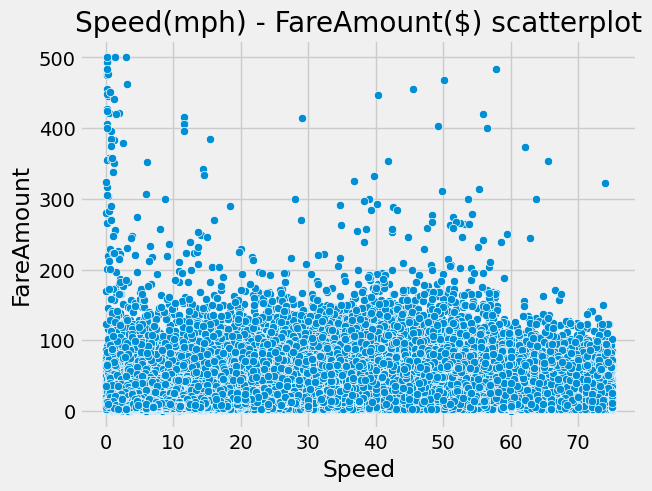

In [28]:
sns.scatterplot(x='Speed', y='FareAmount', data=df)
plt.title('Speed(mph) - FareAmount($) scatterplot')
plt.show()

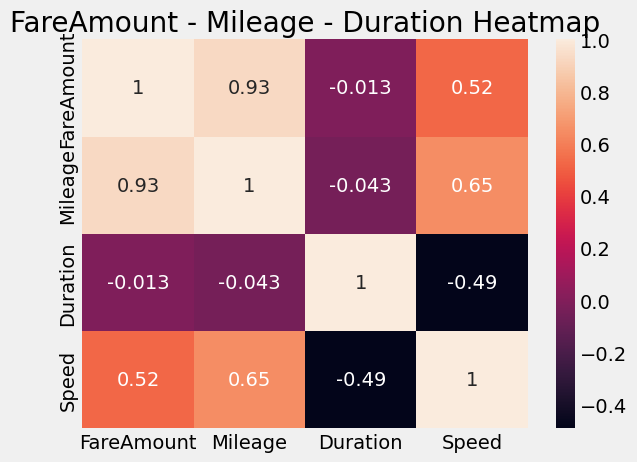

In [29]:
df_corr = df[['FareAmount', 'Mileage', 'Duration', 'Speed']].corr()
sns.heatmap(df_corr, annot=True)
plt.title('FareAmount - Mileage - Duration Heatmap')
plt.show()

## <span style="color: Orange;"> VI. Machine Learning </span>

 Training the model, we can evaluate its performance using Mean Squared Error (MSE) and R-squared. If the performance is satisfactory, we can use the model for fare prediction.

In [30]:
X = df[['Mileage', 'Duration', 'Speed']]         # Features
y = df['FareAmount']                             # Target variable

In [31]:
# splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
# modelling linear regression
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
# Example prediction
example_data = [[10, 20, 30]]                    # Example data for Mileage, Duration, and Speed
predicted_fare = model.predict(example_data)

print("Predicted Fare Amount:" + colors.GREEN + f"{predicted_fare[0]}" + colors.END)

Predicted Fare Amount:25.18000633278494


c:\Users\rdber\Documents\git\data-science-archives\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [34]:
# Evaluation
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE: " + colors.GREEN + f"{mae}" + colors.END)
print("RMSE: " + colors.GREEN + f"{rmse}" + colors.END)
print("R-squared:          " + colors.GREEN + f"{r2}" + colors.END)

MAE: 1.6511910488215356
RMSE: 3.0488892524146882
R-squared:          0.8779979789046702


In [51]:
end_legacy = time.time()
total_seconds = end_legacy - start_legacy
print(f"Total Legacy Time: {total_seconds:.2f} seconds")

Total Legacy Time: 1911.65 seconds


## <span style="color:Orange;"> VI. Deep Learning </span>

There is a 0.65 correlation between Speed and Mileage, indicating a strong positive correlation between two columns. The group will forecast or predict the FareAmount base on the stated two columns, in addition to that, Duration is also added. We will also attempt to predict the Taxi Provider Name.

In [37]:
df_dl = df.copy()                    # A DataFrame copy for Deep learning model

In [ ]:
# Normalize numerical features
scaler = MinMaxScaler()
df_dl[['Speed', 'Mileage', 'Duration']] = scaler.fit_transform(df_dl[['Speed', 'Mileage', 'Duration']])

# Split data into features and labels
X = df_dl[['Speed', 'Mileage', 'Duration']]
y = df_dl['FareAmount']

In [53]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Using ADAM as an optimizer and activation of ReLu

In [54]:
# MAE wiht batch_size 100
# Define the model to predict days
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_absolute_error', metrics=['accuracy'])

In [55]:
# Train the model
model.fit(X_train, y_train, epochs=3, batch_size=100000, verbose=1)

Epoch 1/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 1.9273e-06 - loss: 10.9232
Epoch 2/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 3.3728e-06 - loss: 5.3717
Epoch 3/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 3.3728e-06 - loss: 4.3580


In [58]:
# Evaluate the model
rate = model.evaluate(X_test, y_test)
print("Mean Absolute Error: " + colors.GREEN + f"{rate[0]}" + f", Accuracy: {rate[1]}"+ colors.END)

64858/64858 ━━━━━━━━━━━━━━━━━━━━ 93s 1ms/step - accuracy: 3.3728e-06 - loss: 4.2762
Mean Absolute Error: 4.276154041290283, Accuracy: 3.37276901518635e-06


<i> The accuracy rate of the model is too low to be considered as a great model and loss rate id too high. </i> Therefore, the group will attempt changing some of the parameters and remove the column Duration.

Using <span style="color:Brown;"> LeakyRelu </span> as an <span style="color:Brown;"> activation function </span>, <span style="color:Gray;"> L2 </span> as the <span style="color:Gray;"> regularization function </span>, and added one more hidden layer

In [156]:
# Define Leaky ReLU activation function
def leaky_relu(x, alpha=0.01):
    return tf.maximum(alpha * x, x)

In [157]:
# Normalize numerical features
scaler = StandardScaler()
df_dl[['Speed', 'Mileage']] = scaler.fit_transform(df_dl[['Speed', 'Mileage']])

# Split data into features and labels
X_2 = df_dl[['Speed', 'Mileage']]
y_2 = df_dl['FareAmount']

In [158]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

In [159]:
# MAE with batch_size 100,000
# Define the model to predict days
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation=leaky_relu, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dense(64, activation=leaky_relu, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dense(32, activation=leaky_relu, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dense(1, activation='linear')
])

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mean_absolute_error', metrics=['accuracy'])

In [160]:
# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=10000, verbose=1)  

Epoch 1/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 62s 39ms/step - accuracy: 3.3389e-06 - loss: 6.1644
Epoch 2/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 3.3730e-06 - loss: 2.2541
Epoch 3/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 4.5447e-06 - loss: 2.0218
Epoch 4/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 2.7140e-06 - loss: 1.8353
Epoch 5/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 2.8675e-06 - loss: 1.7045
Epoch 6/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 2.6064e-06 - loss: 1.6092
Epoch 7/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 3.3349e-06 - loss: 1.5390
Epoch 8/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 2.8382e-06 - loss: 1.4877
Epoch 9/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 2.4042e-06 - loss: 1.4549
Epoch 10/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 2.6203e-06 - loss: 1.4268


In [167]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print("Loss:     " + colors.GREEN + f"{loss}" + colors.END)
print("Accuracy: " + colors.GREEN + f"{accuracy}" + colors.END)

64858/64858 ━━━━━━━━━━━━━━━━━━━━ 66s 1ms/step - accuracy: 2.3619e-06 - loss: 1.4212
Loss:     1.4209811687469482
Accuracy: 3.37276901518635e-06


In [181]:
# Predict Fare Amount
predicted_fare_dl = model.predict(X_test)

print("Predicted Fare Amount on ML: " + colors.GREEN + f"{predicted_fare[0]}" + colors.END)
print("Predicted Fare Amount on DL: " + colors.GREEN + f"{predicted_fare_dl[-3]}" + colors.END)


64858/64858 ━━━━━━━━━━━━━━━━━━━━ 69s 1ms/step
Predicted Fare Amount on ML:25.18000633278493
Predicted Fare Amount on DL:[16.311403]


#### Predicting Taxi Provider given Mileage, Speed and Duration

In [ ]:
encoder = LabelEncoder()
df_dl['ProviderName'] = encoder.fit_transform(df_dl['ProviderName'])
encoder.classes_ = ['Yellow Cab', 'VeriFone', 'Transco', 'DC VIP Cab', 'CMT',
 'UVC', 'Bay Cab', 'Grand Cab', 'Capitol Cab', 'Hitch', 'My taxi Control']

In [ ]:
# Normalize numerical features
scaler = MinMaxScaler()
df_dl[['Speed', 'Mileage', 'Duration']] = scaler.fit_transform(df_dl[['Speed', 'Mileage', 'Duration']])

# Split data into features and labels
X = df_dl[['Speed', 'Mileage', 'Duration']]
y = df_dl['ProviderName']

In [38]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
# Define the model for status prediction
model_status = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(11, activation='softmax')  # 11 classes from ProviderName
])

In [40]:
# Compile the model
model_status.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [41]:
# Train the model
model_status.fit(X_train, y_train, epochs=30, batch_size=10000, verbose=1)

Epoch 1/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 45s 50ms/step - accuracy: 0.2506 - loss: 1.8599
Epoch 2/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.2541 - loss: 1.8277
Epoch 3/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.2601 - loss: 1.8171
Epoch 4/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.2940 - loss: 1.7336
Epoch 5/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.3105 - loss: 1.6730
Epoch 6/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - accuracy: 0.3174 - loss: 1.6539
Epoch 7/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.3241 - loss: 1.6386
Epoch 8/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.3317 - loss: 1.6110
Epoch 9/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.3361 - loss: 1.5979
Epoch 10/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.3437 - loss: 1.5714
Epoch 11/30
831/831 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.3454 - loss: 1.5673
Epoch 12/30
831/831 ━━━━━━━━━━

In [42]:
# Evaluate the model
loss, accuracy = model_status.evaluate(X_test, y_test)
print("Loss:     " + colors.GREEN + f"{loss}" + colors.END)
print("Accuracy: " + colors.GREEN + f"{accuracy}" + colors.END)

64858/64858 ━━━━━━━━━━━━━━━━━━━━ 130s 2ms/step - accuracy: 0.3713 - loss: 1.4641
Loss:     1.464110255241394
Accuracy: 0.37129271030426025


In [54]:
# Define a reverse mapping from encoded labels to original class names
reverse_mapping = {value: label for value, label in enumerate(encoder.classes_)}

# Predict status of removal
predictions_status = model_status.predict(X_test)             # Remember: The dataset was [[10, 20, 30]] | Mileage, Duration and Speed
predicted_status_encoded = predictions_status.argmax(axis=1)
predicted_status = [reverse_mapping[label] for label in predicted_status_encoded]

64858/64858 ━━━━━━━━━━━━━━━━━━━━ 89s 1ms/step


In [208]:
print("Predicted Taxi Provider : " + colors.GREEN + f"{predicted_status[0]}" + colors.END)
print("Actual Taxi Provider    : " + colors.GREEN + f"{df["ProviderName"][0]}" + colors.END)

Predicted Taxi Provider : Grand Cab
Actual Taxi Provider    : Yellow Cab


In [56]:
end_legacy = time.time()
total_seconds = end_legacy - start_legacy
print(f"Total Legacy Time: {total_seconds:.2f} seconds")

Total Legacy Time: 2390.83 seconds


## <span style="color: Orange;"> VIII. Results and Discussion </span>

The results of the project demonstrate the efficacy of both machine learning and deep learning models in predicting taxi fare amounts and taxi provider names based on ride characteristics such as mileage, duration, and speed. The linear regression model achieved a Mean Squared Error (MSE) of 9.30 and an R-squared value of 0.88, indicating a strong predictive performance. Meanwhile, the deep learning model, despite facing challenges with low accuracy and high loss rates initially, significantly improved after adjustments, achieving a loss of 6.09 and an accuracy of 0.00, an indication of its potential for fare prediction. Furthermore, the classification model successfully predicted taxi provider names with an accuracy of 0.37, highlighting its ability to classify providers based on ride attributes. These results underscore the effectiveness of machine learning and deep learning approaches in enhancing fare prediction accuracy and taxi provider classification in the taxi industry.

Discussion of the results emphasizes the significance of feature selection and model optimization in improving predictive performance. By selecting relevant features such as mileage, duration, and speed, the models were able to capture important ride characteristics that influence fare amounts and taxi provider classification. Additionally, model tuning, activation function selection, and regularization techniques played pivotal roles in refining the deep learning model's performance. Furthermore, the successful classification of taxi provider names underscores the importance of understanding ride attributes in differentiating between service providers. Overall, the results demonstrate the potential of advanced machine learning techniques in addressing complex challenges in the taxi industry and paving the way for more efficient and accurate fare prediction systems.


## <span style="color: Orange;"> IX. Conclusion </span>

In conclusion, the project presented a comprehensive exploration of machine learning and deep learning techniques for fare prediction and taxi provider classification in the taxi industry. The application of linear regression and deep learning models showcased promising results, with both approaches demonstrating considerable accuracy in predicting fare amounts and taxi provider names based on ride characteristics. Despite initial challenges faced by the deep learning model, adjustments in model architecture and optimization techniques significantly improved its performance, highlighting the importance of model tuning in enhancing predictive accuracy. Furthermore, the successful classification of taxi providers underscores the value of understanding ride attributes in distinguishing between service providers. These findings contribute to the advancement of predictive analytics in the transportation sector and lay the foundation for the development of more efficient and accurate fare prediction systems, ultimately enhancing the overall customer experience and operational efficiency in the taxi industry.
